# FACULTAD DE INGENIERÍA - BIOINGENIERÍA
# Bioseñales y Sistemas - Segundo Proyecto 
## **INFORME DE RESULTADOS: Clasificación de Datos BCI**

*Maria José Rios Hurtado*  
*Mónica Alejandra Hinestroza Chaparro*


El presente proyecto tiene como objetivo analizar señales electroencefalográficas (EEG) registradas durante tareas de imaginación motora de la mano izquierda y derecha, así como durante estados de reposo, utilizando datos provenientes del conjunto de datos ds004362 de OpenNeuro. Para el desarrollo del proyecto se implementa un flujo completo de procesamiento de señales biomédicas en Python, que incluye etapas de preprocesamiento, segmentación de la señal, extracción de características y clasificación automática de estados cerebrales. Inicialmente, las señales EEG son filtradas para eliminar ruido y artefactos, posteriormente se segmentan en épocas asociadas a cada condición experimental y se calculan diferentes índices neurofisiológicos de interés; esto fue realizado en el proyecto 1 y es reutilizado e implementado nuevamente en el presente proyecto.

Entre las características extraídas se encuentran la densidad espectral de potencia (PSD) en las bandas mu (8–13 Hz) y beta (13–30 Hz), la coherencia espectral entre regiones motoras, la entropía espectral y los parámetros de Hjorth, las cuales permiten describir aspectos relacionados con la potencia neuronal, la conectividad funcional, la complejidad y la dinámica temporal de la actividad cerebral. Estas características son utilizadas como variables de entrada para algoritmos de aprendizaje automático orientados a la clasificación de los diferentes estados mentales evaluados.

Finalmente, se comparó el desempeño de distintas arquitecturas de redes neuronales multicapa (MLP), así como de los algoritmos Máquina de Soporte Vectorial (SVM) y Extreme Gradient Boosting (XGBoost), mediante métricas de desempeño y matrices de confusión. Los resultados permiten evaluar la capacidad de las características extraídas para discriminar entre estados de reposo, imaginación de movimiento de la mano izquierda e imaginación de movimiento de la mano derecha, contribuyendo al estudio y desarrollo de sistemas BCI no invasivos basados en EEG.


### **ÍNDICES**

### **Discusión de las diferencias en las condiciones para los diferentes índices usando las gráficas obtenidas usando estadística descriptiva**

**PSD (Densidad Espectral de Potencia)**


Los boxplots de la PSD en las bandas mu (8–13 Hz) y beta (13–30 Hz) sobre los canales C3, C4 y Cz revelan un patrón: Las tres condiciones presentan distribuciones de potencia muy similares y ampliamente superpuestas, con medianas prácticamente equivalentes en todos los canales. La diferencia más visible no está en la tendencia central sino en los valores atípicos superiores, que son más extremos en REST, reflejando episodios de mayor potencia esporádicos en estado de reposo. Este comportamiento refleja el fenómeno de desincronización relacionada con eventos (ERD), en el cual la activación cortical asociada a la imaginación de movimiento suprime los ritmos sensoriomotores mu y beta, reduciendo la potencia registrada en los canales de la corteza sensoriomotora.

La lateralización esperada entre C3 y C4 no es visualmente evidente en los boxplots dado el alto solapamiento entre condiciones. Las diferencias estadísticas detectadas por Kruskal-Wallis son reales pero de pequeña magnitud, explicadas en gran parte por el elevado tamaño muestral (n=9,835 épocas) más que por una separación clínica robusta. Sin embargo, la separación entre MI_L y MI_R en términos de PSD es limitada, lo que sugiere que este índice, si bien discrimina bien REST vs. condiciones motoras, presenta menor capacidad para diferenciar los dos tipos de imaginería motora entre sí.

La banda beta muestra un comportamiento similar al mu, con la condición REST presentando mayor potencia en todos los canales. Las distribuciones presentan alta variabilidad inter-sujeto, reflejada en los rangos intercuartílicos amplios y la presencia de valores atípicos, lo cual es característico de datos EEG multiusuario donde existen diferencias individuales significativas en la amplitud y frecuencia de los ritmos sensoriomotores.


**COHERENCIA**


Los boxplots de coherencia espectral entre los pares de canales C3–C4, C3–Cz y C4–Cz en las bandas mu y beta revelan patrones de conectividad funcional diferenciados según la condición experimental. En general, los valores de coherencia son moderados (rango típico 0.2–0.6), lo que es consistente con la naturaleza no estacionaria del EEG y con el hecho de que la coherencia captura sincronización funcional entre regiones, no solo actividad local.

El heatmap de coherencia media por condición revela que las diferencias entre REST, MI_L y MI_R son de magnitud muy pequeña. Por ejemplo, la coherencia mu en C3C4 varía apenas entre 0.322 (REST), 0.316 (MI_L) y 0.318 (MI_R), una diferencia de 0.004–0.006 puntos. Aunque estas diferencias alcanzan significancia estadística debido al gran tamaño muestral, su relevancia práctica para un sistema BCI es limitada. El par con mayor coherencia en todas las condiciones es C4Cz en banda mu (~0.435–0.442), mientras que C3C4 presenta consistentemente los valores más bajos (~0.316–0.322), sugiriendo menor sincronización interhemisférica que ipsilateral independientemente de la condición.

La coherencia en el par C3–Cz en la banda mu (coh_mu_C3Cz, p = 0.001425) mostró diferencias principalmente entre REST y MI_R, sugiriendo que la imaginación del movimiento derecho modifica la comunicación entre la región sensoriomotora izquierda y la línea media. La coherencia C4–Cz en beta (coh_beta_C4Cz) también fue significativa (p = 0.000823), con diferencias principalmente entre REST y MI_L. En cambio, coh_mu_C3C4 (p = 0.061) y coh_beta_C3Cz (p = 0.080) no alcanzaron significancia estadística, lo que indica que no toda combinación de canales y bandas es igualmente informativa.


**ENTROPÍA ESPECTRAL**

Los boxplots muestran distribuciones de entropía muy similares entre las tres condiciones en todos los canales, con medianas en torno a 0.70–0.72 y rangos intercuartílicos amplios que se solapan casi completamente. Las diferencias son estadísticamente significativas (p < 0.001 en C3 y C4) pero visualmente sutiles, lo que nuevamente refleja el efecto del tamaño muestral sobre la potencia estadística más que una separación clínicamente evidente. 

En C3 y C4, las pruebas estadísticas confirmaron diferencias significativas tanto en REST vs. MI_L como en REST vs. MI_R (p < 0.001 en ambos casos), con valores de entropía claramente superiores durante las tareas motoras. En Cz la diferencia también fue estadísticamente significativa (p = 0.021), aunque de menor magnitud, lo que es esperable dado que Cz es un canal de línea media menos especializado en funciones motoras lateralizadas.

La entropía espectral resultó ser uno de los índices más discriminativos para separar REST de las condiciones motoras. A pesar de la similitud visual entre condiciones, la entropía sigue siendo una característica válida para clasificación dado que su significancia estadística fue confirmada. Sin embargo, su aporte discriminativo real es modesto comparado con lo esperado teóricamente. Adicionalmente, la correlación negativa entre entropía y complejidad de Hjorth (r = -0.858 en C3) indica que ambas medidas capturan información parcialmente redundante sobre la irregularidad de la señal.


**PARÁMETROS DE HJORTH**


Los parámetros de Hjorth (Actividad, Movilidad y Complejidad) aportaron información relevante en el dominio temporal, complementaria a los índices espectrales. La Actividad de Hjorth, que refleja la potencia cuadrática de la señal, mostró diferencias significativas en todos los canales (C3: p < 0.001; C4: p < 0.001; Cz: p < 0.001) con mayor actividad en REST, en coherencia con los hallazgos de la PSD. Esto confirma que la potencia total de la señal es mayor en reposo que durante imaginería motora.

La Movilidad, que refleja el contenido de frecuencia dominante de la señal, mostró diferencias significativas en C3 (p = 0.000002) y C4 (p < 0.001), con valores que sugieren un desplazamiento en la frecuencia media durante las tareas motoras. La Complejidad de Hjorth, que mide cuánto se aleja la señal de una oscilación sinusoidal pura, fue significativa en C3 (p = 0.000003) y C4 (p < 0.001), siendo mayor durante las condiciones motoras, lo que indica que la señal se vuelve más irregular cuando la corteza motora se activa. En Cz, los parámetros de Movilidad (p = 0.396) y Complejidad (p = 0.940) no mostraron diferencias significativas, confirmando que este canal es menos sensible a la lateralización motora.

Un hallazgo importante de la matriz de correlación fue la alta redundancia entre la Actividad de Hjorth y la PSD mu/beta en el mismo canal (r ≈ 0.95–0.97), lo que era esperable dado que ambas miden esencialmente la potencia de la señal por caminos diferentes. Esta redundancia motivó la selección final de características para clasificación.


### **Planteamiento de las hipótesis nulas y alternativas. Pruebas estadísticas y discusión de los resultados**

#### **Hipótesis**

- **PSD**

    H₀: No existen diferencias en potencia mu entre reposo, MI_L y MI_R.

    H₁: Existen diferencias significativas en potencia mu entre las condiciones.

- **Coherencia**

    H₀: La conectividad funcional entre canales no cambia entre condiciones.

    H₁: La conectividad funcional cambia significativamente entre condiciones.

- **Entropía**

    H₀: La complejidad espectral permanece constante entre condiciones.

    H₁: La complejidad espectral varía significativamente entre estados.

#### **Pruebas estadísticas y discusión de resultados**

**Metodología estadística aplicada**

Dado que la prueba de normalidad de Shapiro-Wilk rechazó la hipótesis de normalidad para las 24 características evaluadas (todas con normalidad = False), se aplicó la prueba no paramétrica de Kruskal-Wallis para la comparación global entre las tres condiciones (REST, MI_L, MI_R), con un nivel de significancia α = 0.05. Para las comparaciones por pares se utilizó Mann-Whitney U con corrección de Bonferroni (α corregido = 0.05 / 72 comparaciones). Del total de 24 características, **20 resultaron estadísticamente significativas** en la prueba global de Kruskal-Wallis.

**Resultados PSD — se rechaza H₀**

Todos los índices de PSD resultaron significativos (p < 0.001 en mu_C3, mu_C4, beta_C3, beta_C4; p = 0.000003 en beta_Cz). Las comparaciones post-hoc revelaron que REST vs. MI_L y REST vs. MI_R son las diferencias más consistentes y de mayor significancia. En cambio, la comparación MI_L vs. MI_R fue significativa solo en mu_C4 (p = 0.000002) y beta_C4 (p = 0.003955), lo que indica que la PSD puede diferenciar ambas lateralidades principalmente a través del canal C4. Se rechaza H₀ para todos los índices de PSD.

_Figura 1. Distribución de la PSD en banda mu y beta por condición (REST, MI_L, MI_R) en canales C3, C4 y Cz_
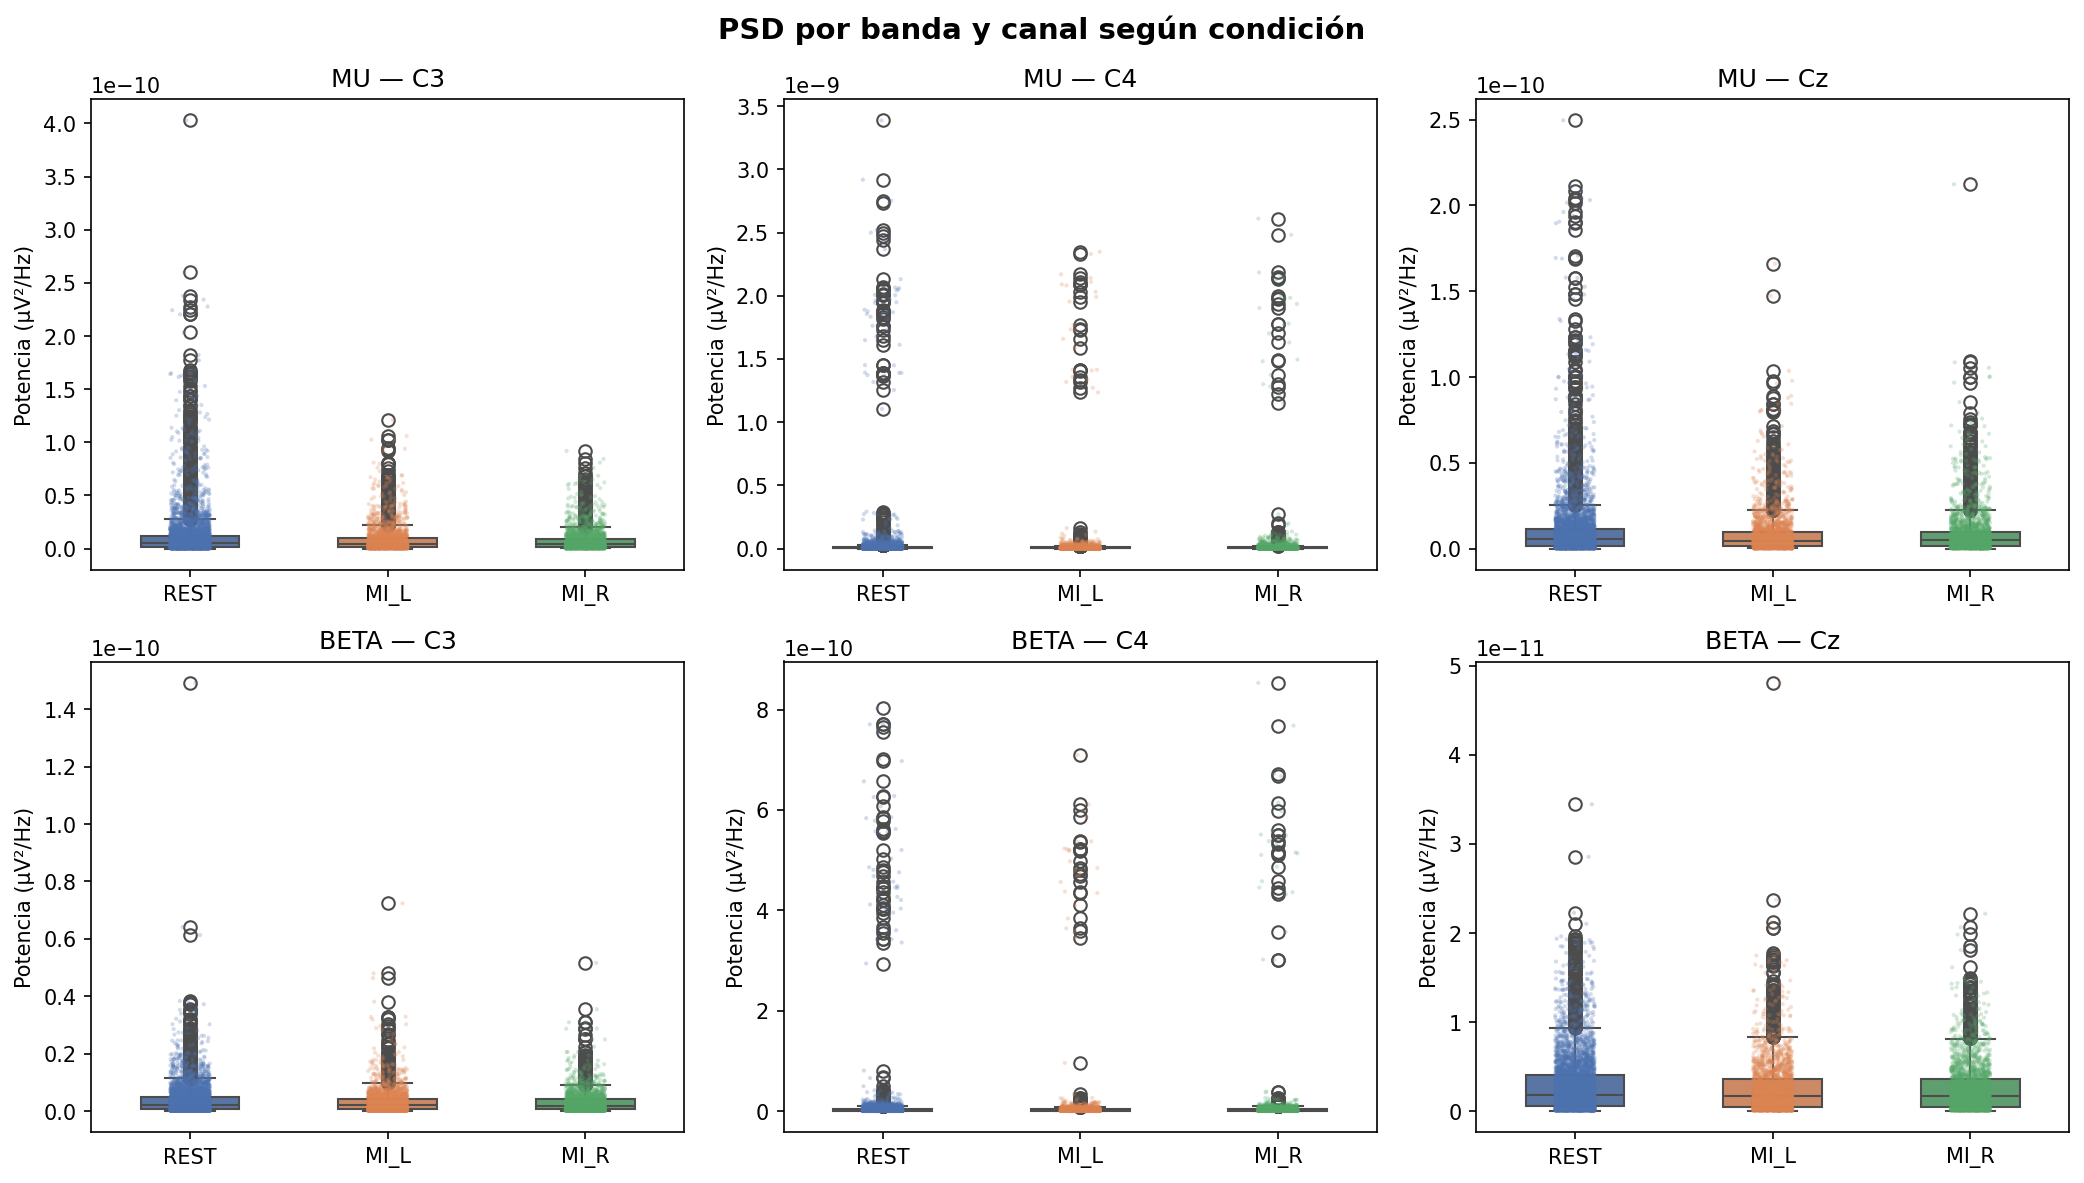

**Resultados Coherencia — resultados mixtos**

De los seis índices de coherencia, cuatro resultaron significativos: coh_beta_C3C4 (p = 0.000087), coh_mu_C3Cz (p = 0.001425), coh_mu_C4Cz (p = 0.034680) y coh_beta_C4Cz (p = 0.000823). Los dos restantes —coh_mu_C3C4 (p = 0.061) y coh_beta_C3Cz (p = 0.080)— no alcanzaron significancia estadística, por lo que para estas características no se rechaza H₀. Las comparaciones post-hoc muestran que las diferencias significativas de coherencia son principalmente entre REST y las condiciones motoras, y no tanto entre MI_L y MI_R, lo que sugiere que la coherencia distingue bien el estado motor del estado de reposo pero tiene menor capacidad para diferenciar lateralidad.

_Figura 2. Distribución de coherencia espectral en banda mu y beta por condición_
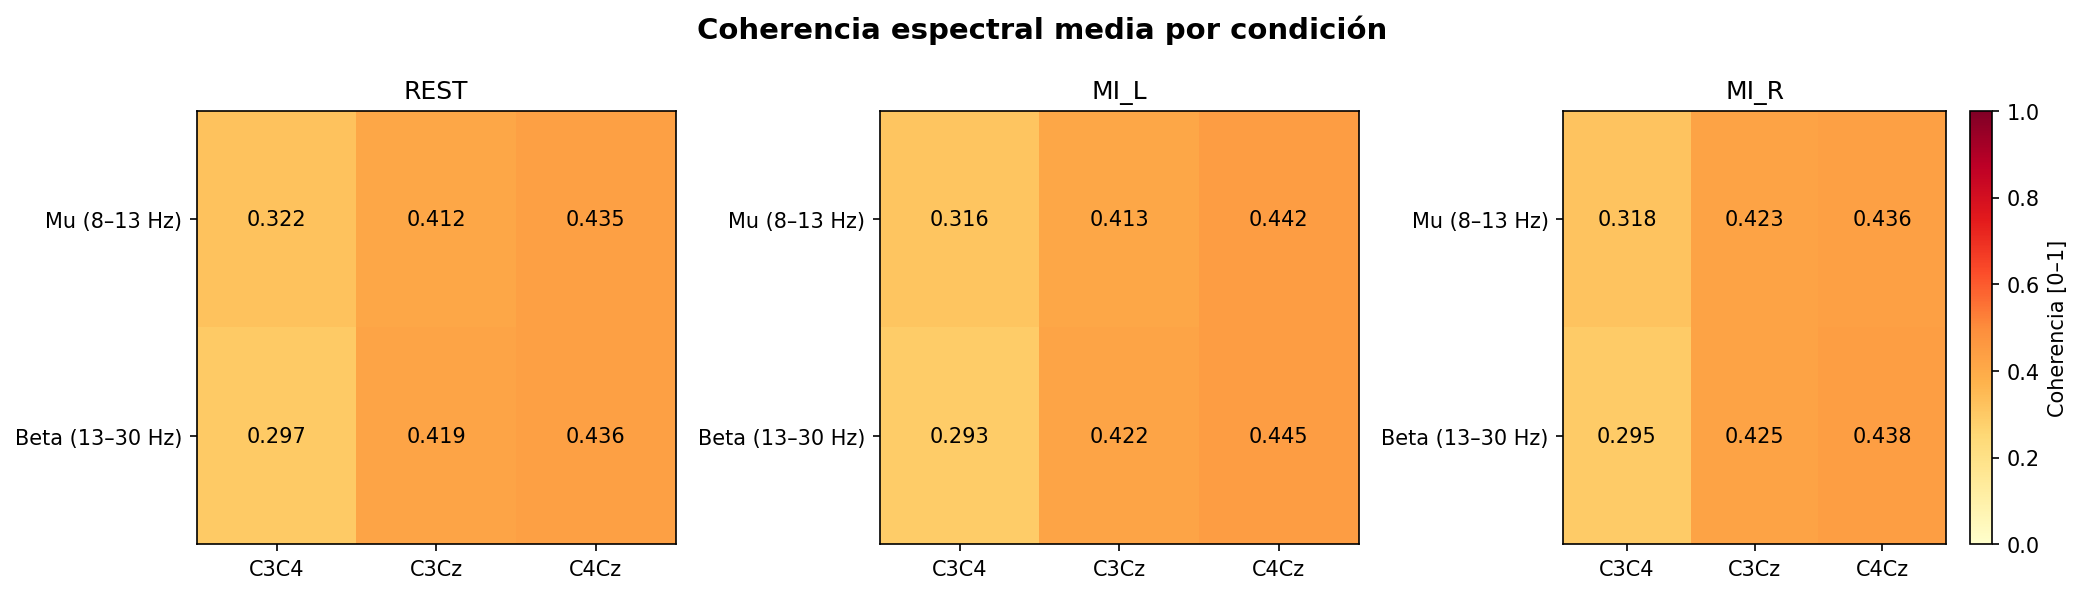

_Figura 3. Distribución de coherencia espectral por canales y condición_
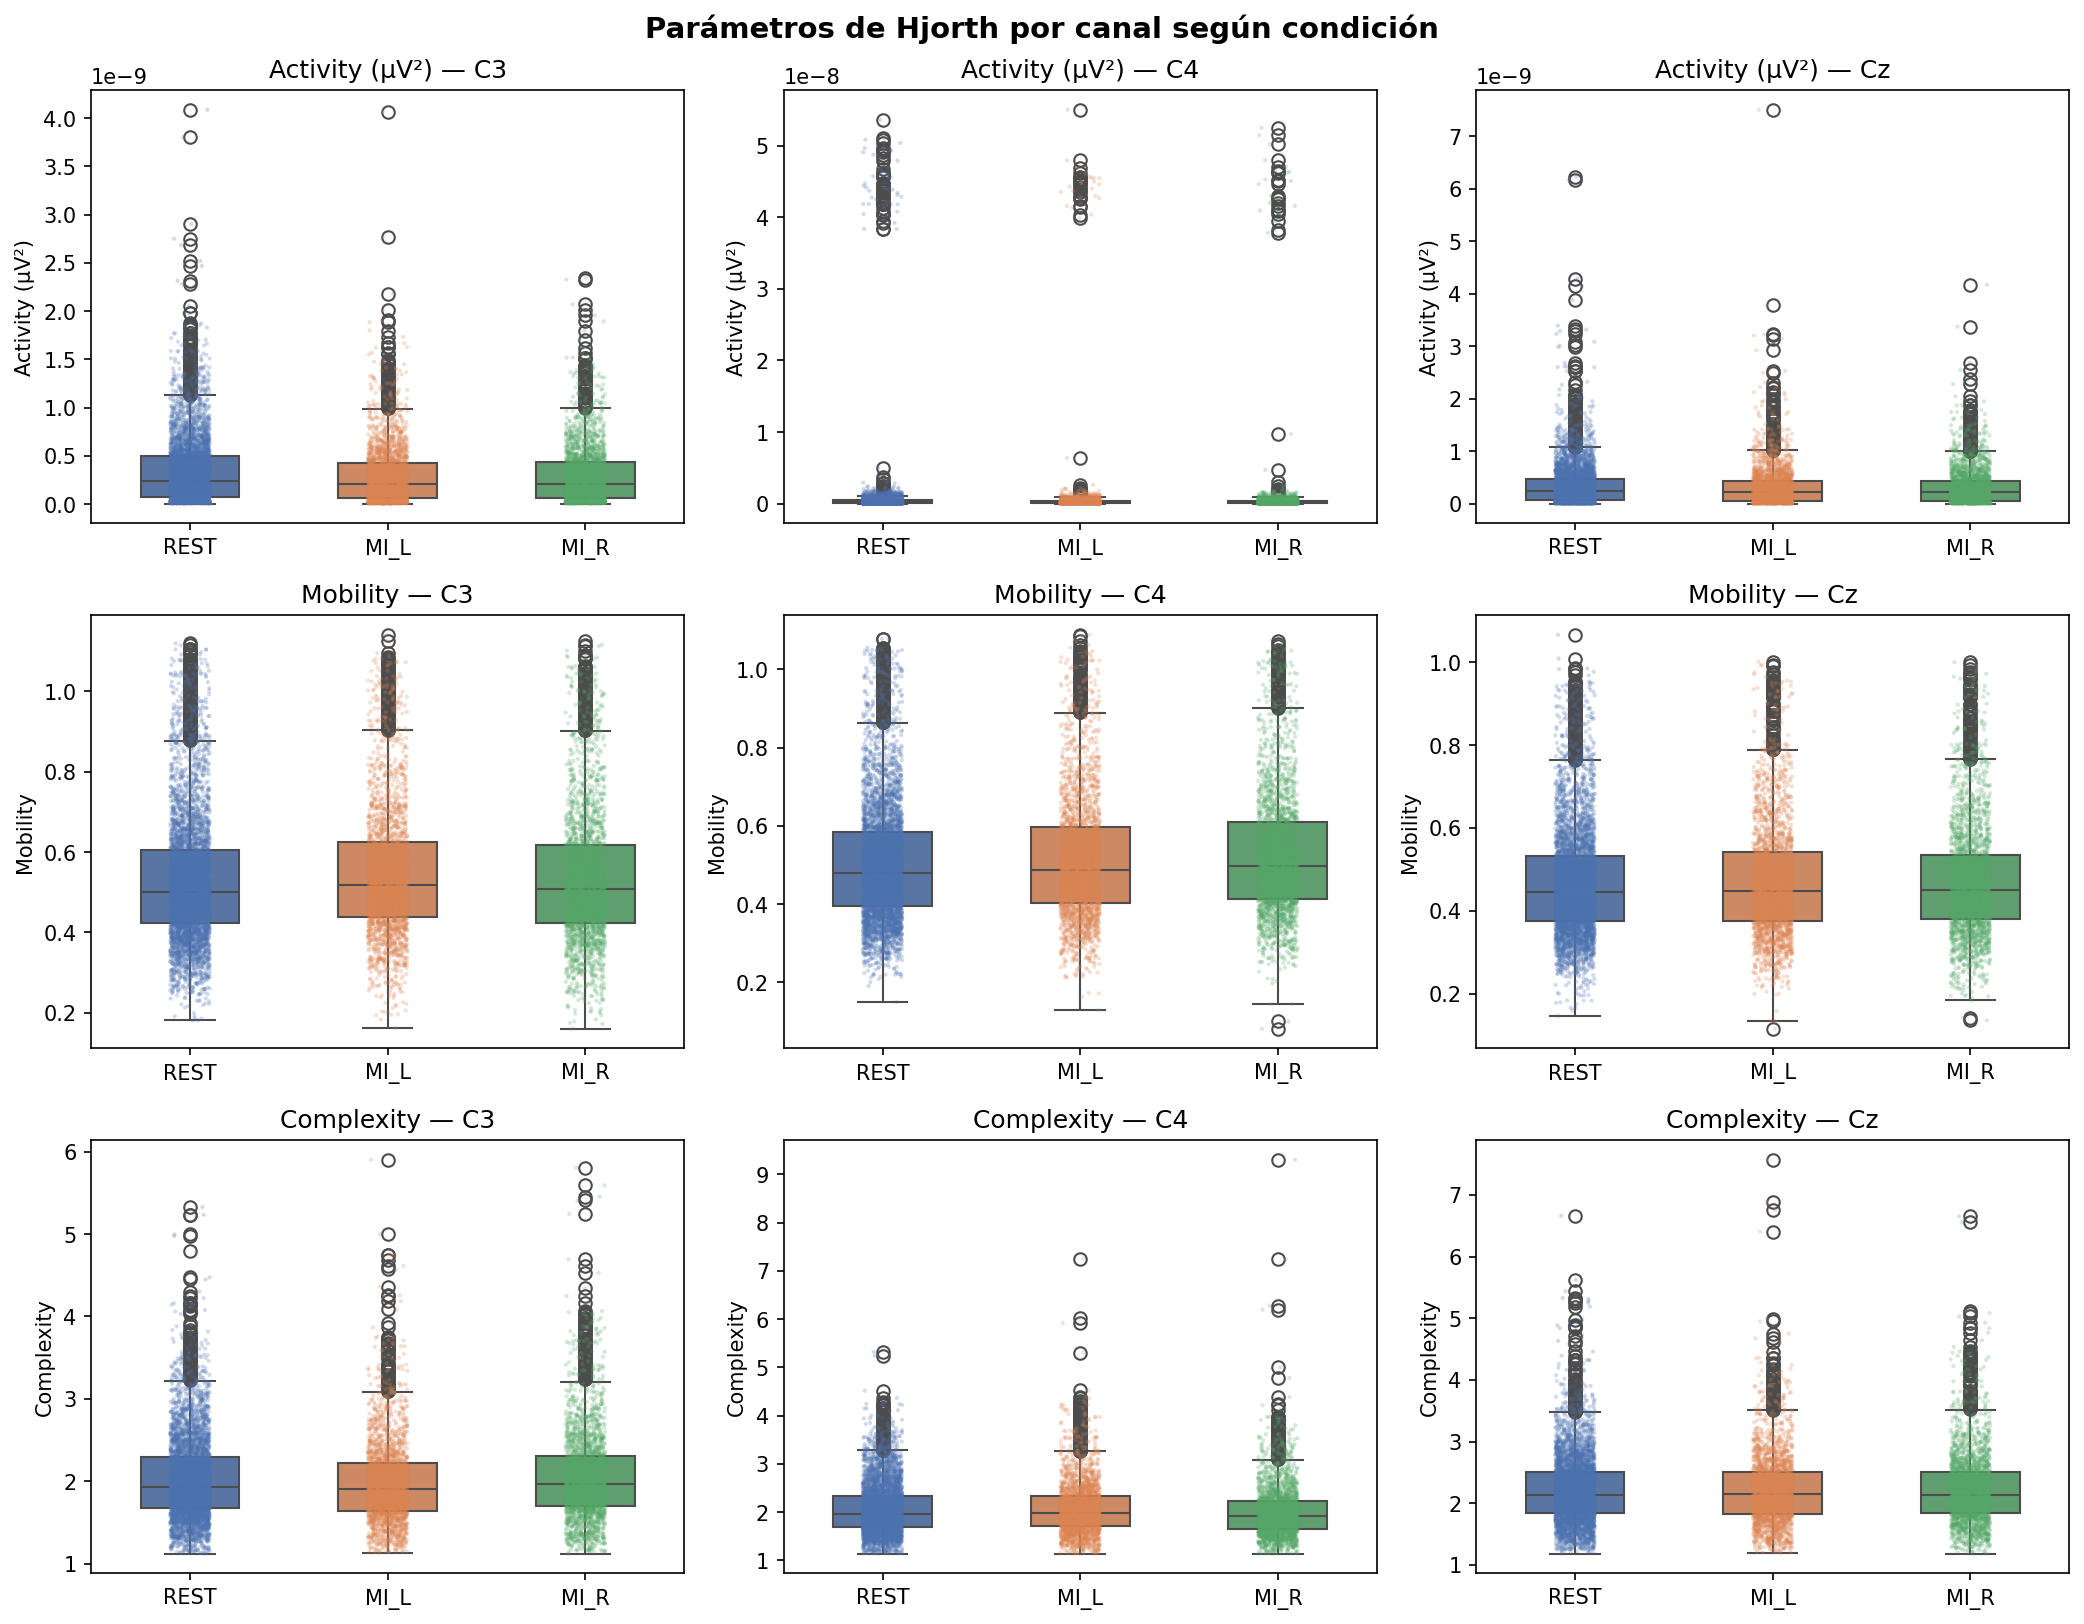

**Resultados Entropía — se rechaza H₀**

Los tres índices de entropía resultaron significativos: ent_C3 (p < 0.001), ent_C4 (p < 0.001) y ent_Cz (p = 0.021). Para ent_C3, las comparaciones post-hoc mostraron diferencias tanto en REST vs. MI_L (p < 0.001), REST vs. MI_R (p < 0.001) y también MI_L vs. MI_R (p = 0.015), haciendo de la entropía en C3 uno de los índices más informativos para la clasificación triclase. Para ent_C4, el patrón fue similar. Se rechaza H₀ para los tres índices de entropía.

_Figura 4. Distribución de entropía espectral por canal (C3, C4, Cz) y condición_
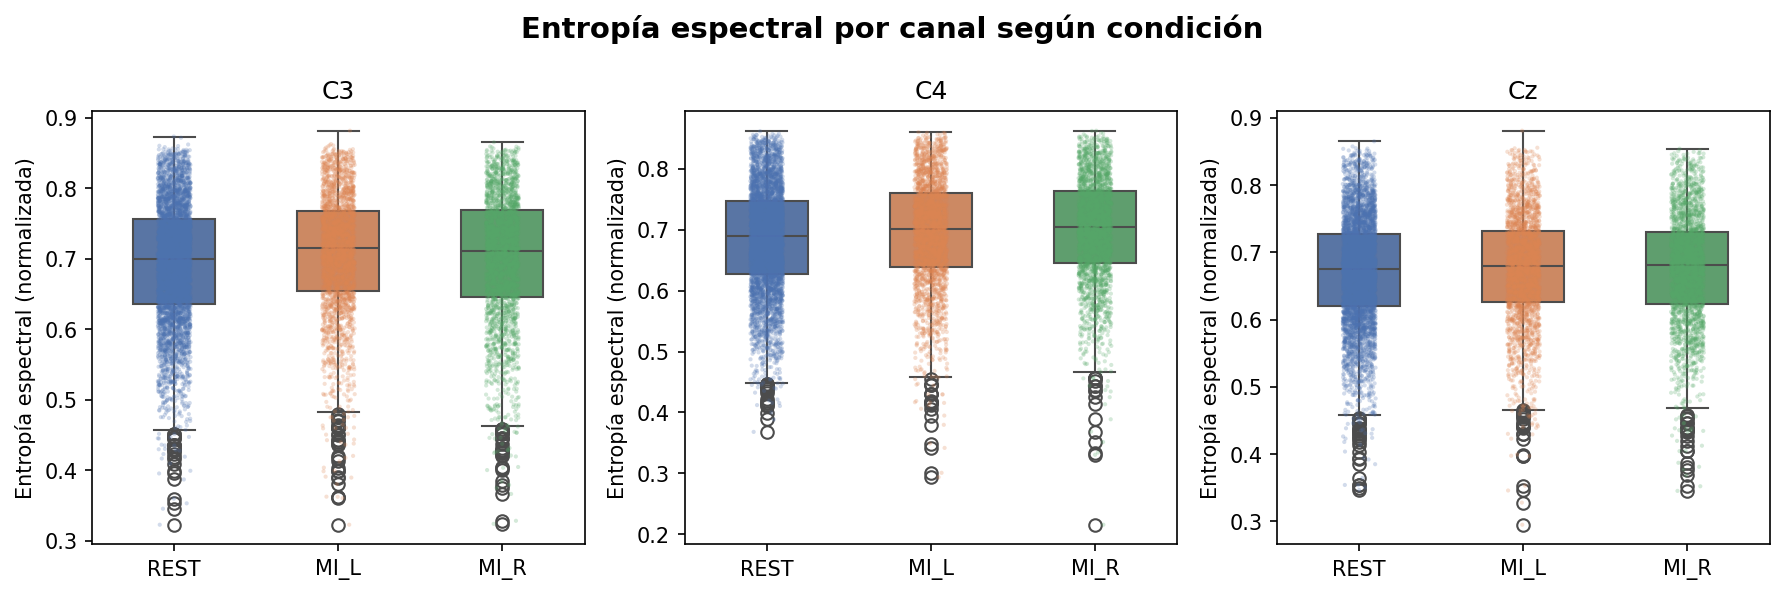

**Características no significativas**

Cuatro características no rechazaron H₀: coh_mu_C3C4 (p = 0.061), coh_beta_C3Cz (p = 0.080), hjorth_mob_Cz (p = 0.396) y hjorth_comp_Cz (p = 0.940). Estas características fueron excluidas del conjunto de entrada para los clasificadores.

_Figura 5. Selección de características._
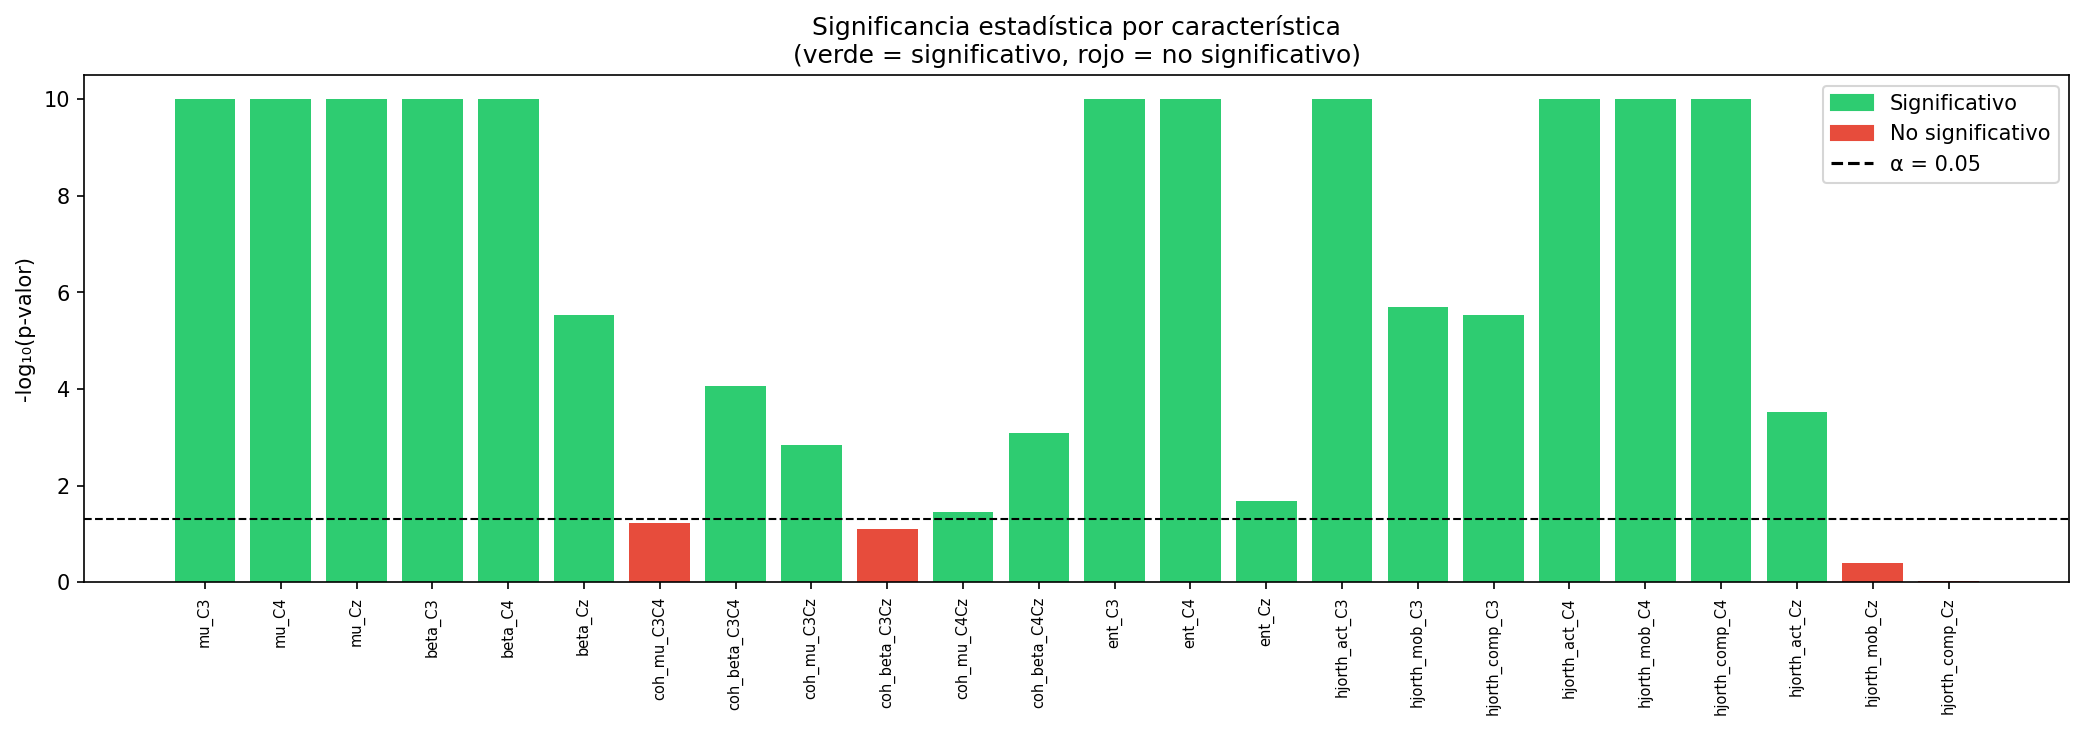

**Selección final de características**

Con base en el criterio de significancia estadística y la eliminación de pares altamente correlacionados (|r| > 0.85: beta_C4↔mu_C4, beta_C4↔hjorth_act_C4, hjorth_act_C4↔mu_C4, ent_C3↔hjorth_comp_C3, ent_C4↔hjorth_mob_C4, ent_Cz↔hjorth_mob_Cz, ent_Cz↔hjorth_comp_Cz), se seleccionaron las **8 características más discriminativas** ordenadas por valor p: mu_C3, mu_C4, mu_Cz, beta_C3, beta_C4, hjorth_act_C3, ent_C3 y ent_C4.

_Figura 6. Matriz de correlación entre las 24 características extraídas_
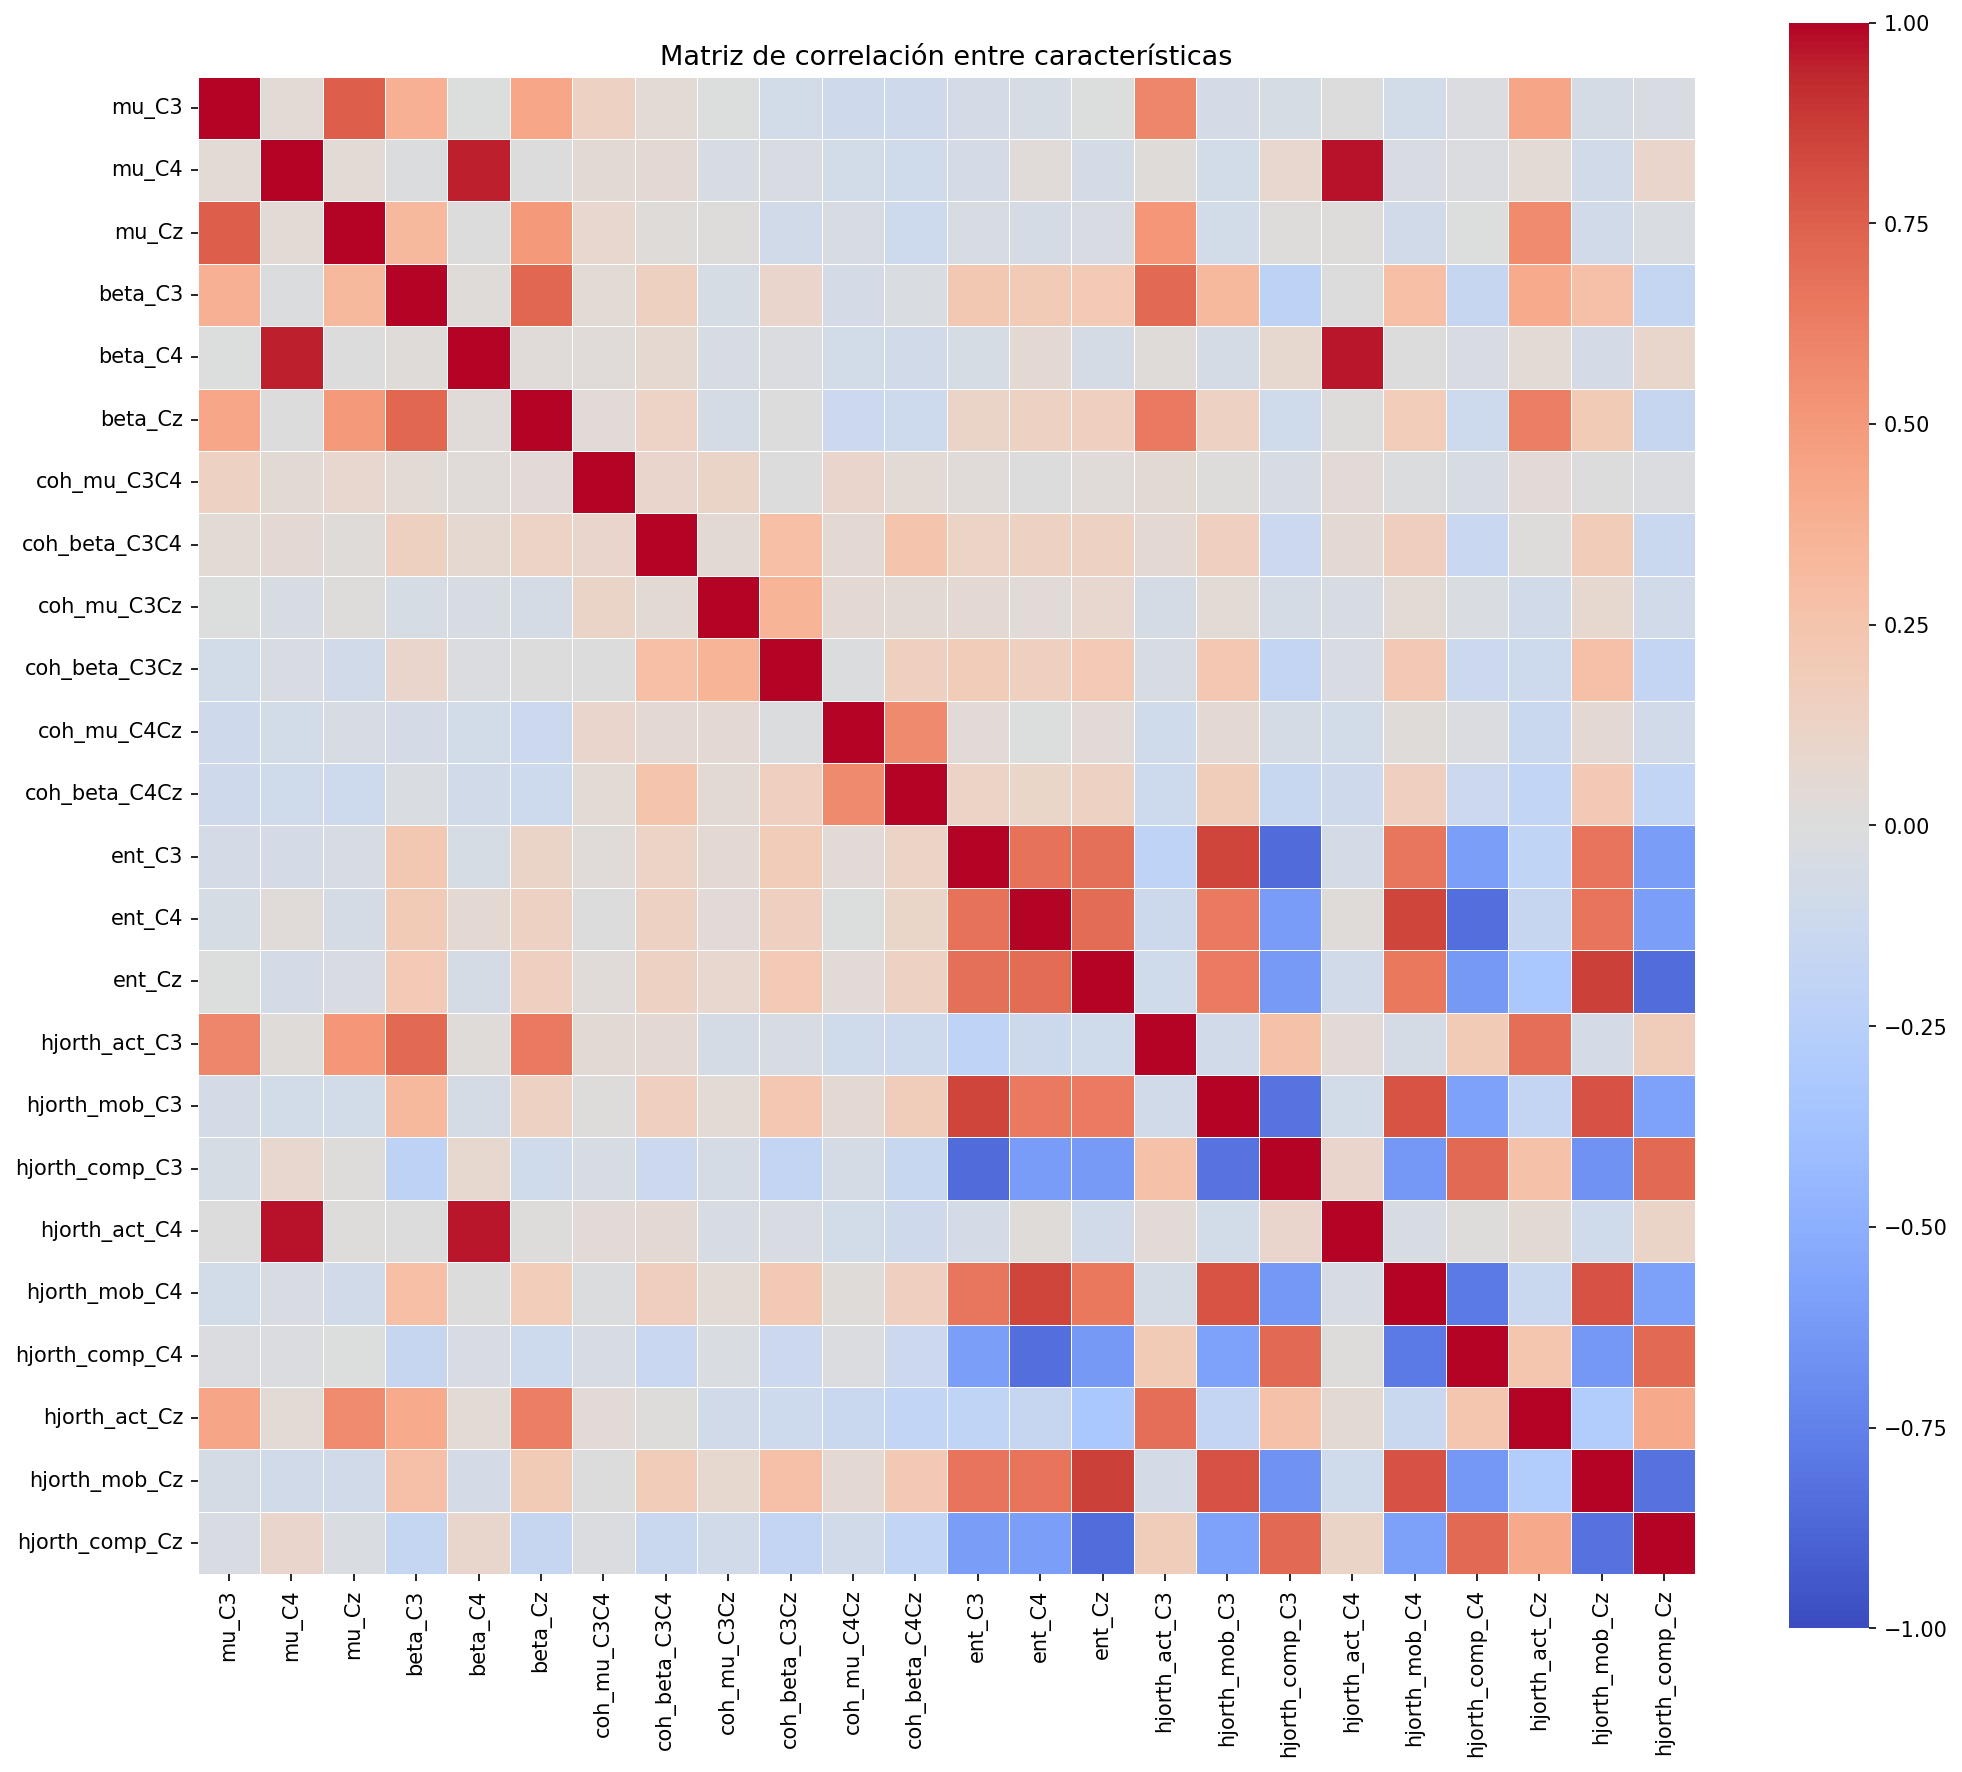

### **CLASIFICACIÓN**

### **Análisis de resultados: arquitecturas de red y matrices de confusión**



#### **Estrategia de evaluación**

Todos los modelos fueron evaluados mediante validación cruzada estratificada (StratifiedKFold, k=10) sobre las 8 características seleccionadas, normalizadas con StandardScaler. La validación estratificada garantiza que cada fold mantenga la proporción de clases del dataset original (REST ≈ 50%, MI_L ≈ 25%, MI_R ≈ 25%), evitando sesgos asociados al desbalance de clases. Los resultados reportados corresponden a la accuracy media ± desviación estándar sobre los 10 folds.

_Figura 7. Distribución de datos en cada fold — StratifiedKFold k=10_
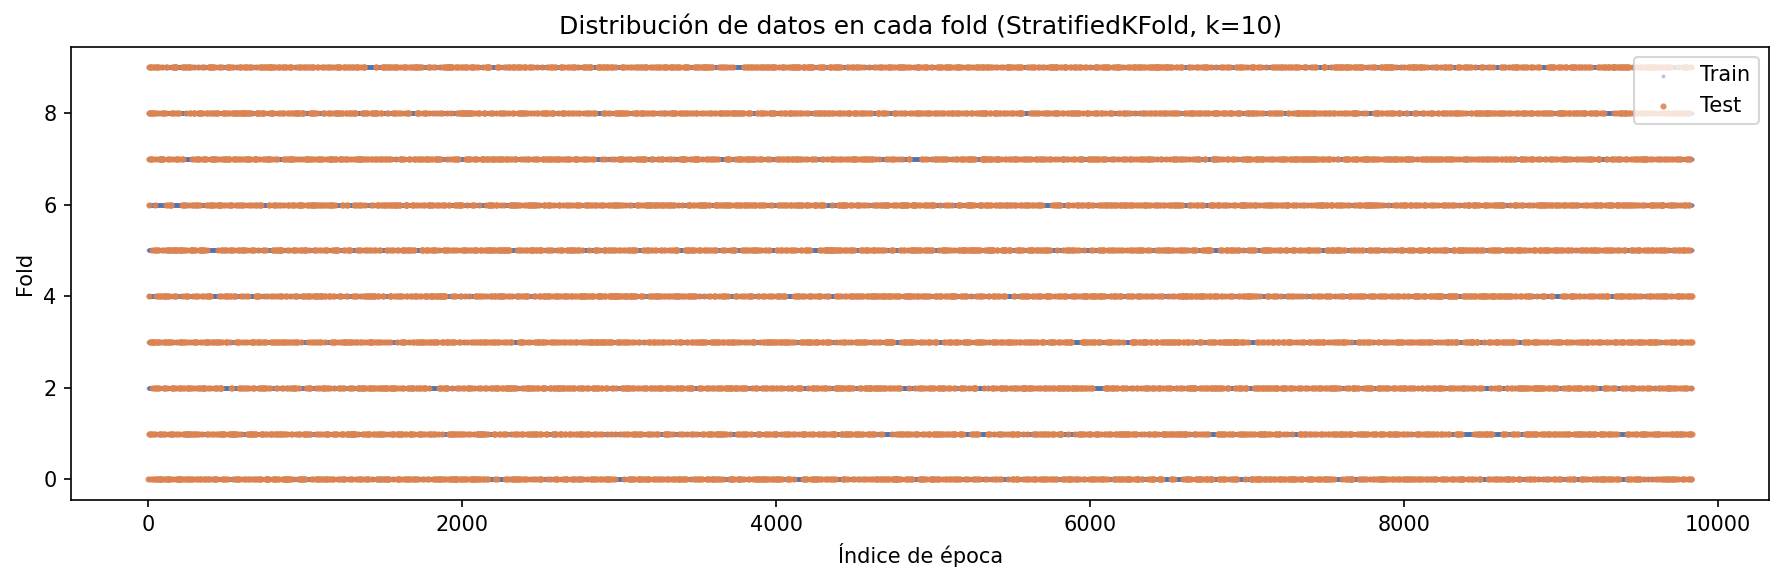

#### **Arquitectura 1 — MLP1 (8,): una capa oculta, regla 2/3·entrada + salida**

La primera arquitectura sigue la regla heurística clásica para dimensionar la capa oculta: n = (2/3)×8 + 3 = 8.33 neuronas → redondeado a 8 en la implementación. Tiene una sola capa oculta, lo que la hace la red de menor capacidad de representación del conjunto evaluado. Su función de activación por defecto es ReLU y el optimizador es Adam con max_iter=1000.

**Resultado:** Accuracy = **0.4986 ± 0.0052**

La matriz de confusión confirma que MLP1 clasifica casi todas las épocas como REST: de 496 épocas MI_L reales solo 6 se predicen correctamente (recall = 0.012), y de 487 MI_R solo 21 se predicen correctamente (recall = 0.043). El modelo aprende el sesgo de la clase mayoritaria y prácticamente ignora las clases motoras. El accuracy apenas supera el azar teórico para tres clases (33.3%), lo que sugiere que esta arquitectura mínima no es suficiente para capturar las no linealidades del problema.

#### **Arquitectura 2 — MLP2 (8,): una capa oculta con igual número de neuronas que entradas**

La segunda arquitectura también tiene una única capa oculta, pero su tamaño es igual al número de características de entrada (8 neuronas), lo que teóricamente ofrece mayor capacidad de representación respecto a MLP1 al permitir aprender combinaciones más ricas de las características de entrada.

**Resultado:** Accuracy = **0.4986 ± 0.0052**

MLP2 produce exactamente los mismos valores en la matriz de confusión que MLP1 (950/10/24 para REST, 473/6/17 para MI_L, 461/5/21 para MI_R), confirmando que ambas arquitecturas convergen a la misma solución trivial de predecir mayoritariamente REST. Este resultado indica que aumentar el ancho de la capa oculta sin añadir profundidad no mejora la capacidad discriminativa cuando las características de entrada no son linealmente separables.

#### **Arquitectura 3 — MLP3 (8, 4): dos capas ocultas**

La tercera arquitectura introduce profundidad con dos capas ocultas (8 y 4 neuronas), lo que permite modelar representaciones jerárquicas. La primera capa aprende combinaciones de primer orden entre características; la segunda capa aprende combinaciones de esas combinaciones, potencialmente capturando interacciones más complejas entre bandas de frecuencia y canales.

**Resultado:** Accuracy = **0.4989 ± 0.0063**

MLP3 obtiene una mejora marginal sobre MLP1 y MLP2 (diferencia < 0.1 pp), pero el patrón de confusión es similar. La desviación estándar ligeramente mayor (0.0063 vs. 0.0052) sugiere mayor varianza en el aprendizaje entre folds, lo que puede deberse a que la mayor capacidad del modelo introduce mayor sensibilidad a la distribución particular de cada fold. En términos prácticos, la adición de profundidad no produce mejoras significativas con este conjunto de características.

#### **SVM con kernel RBF**

La Máquina de Soporte Vectorial con kernel RBF proyecta los datos a un espacio de mayor dimensión donde las clases pueden ser linealmente separables. El parámetro C=1.0 controla el equilibrio entre maximizar el margen de separación y minimizar los errores de entrenamiento.

**Resultado:** Accuracy = **0.4993 ± 0.0012**

El SVM obtiene accuracy comparable a las redes MLP y destaca por tener la menor desviación estándar de todos los modelos (0.0012), lo que indica alta estabilidad en la estimación del desempeño entre folds. La matriz de confusión del SVM muestra el caso más extremo: clasifica el 100% de las épocas MI_L y MI_R como REST (recall = 0 para ambas clases motoras), con valores normalizados de 1.0, 0.0, 0.0 en ambas filas. Es el modelo más conservador del conjunto, sacrificando completamente la discriminación de clases minoritarias en favor de la clase mayoritaria. Históricamente, el SVM-RBF ha sido uno de los clasificadores más populares en BCI por su buen desempeño con pocas muestras de entrenamiento, pero en este caso el desbalance de clases y la baja separabilidad de las características limitan su rendimiento.

#### **XGBoost**

Extreme Gradient Boosting construye un ensamble de 100 árboles de decisión de forma secuencial: cada árbol nuevo corrige los errores del ensamble anterior. Su capacidad para manejar automáticamente características irrelevantes y su robustez a la escala de los datos lo hacen un competidor sólido en clasificación tabular.

**Resultado:** Accuracy = **0.5129 ± 0.0097**

XGBoost fue el modelo con mayor accuracy, superando en aproximadamente 1.4 puntos porcentuales a los MLP y al SVM. Si bien la diferencia es pequeña en términos absolutos, es notable que sea el único modelo que supera el umbral de 0.50 de forma consistente. La desviación estándar más alta (0.0097) refleja la mayor capacidad del modelo para adaptarse a cada fold, lo cual es un arma de doble filo.  XGBoost es el único modelo que realmente intenta clasificar las condiciones motoras. Su matriz muestra recall de 0.093 para MI_L (46 de 496 épocas correctas) y 0.09 para MI_R (44 de 487 épocas correctas), valores bajos pero notoriamente superiores al 0 de SVM y al ~0.01–0.04 de los MLP. También es el único que distribuye predicciones entre las tres clases de forma más balanceada (REST: 917/29/38).

_Figura 8. Matrices de confusión._
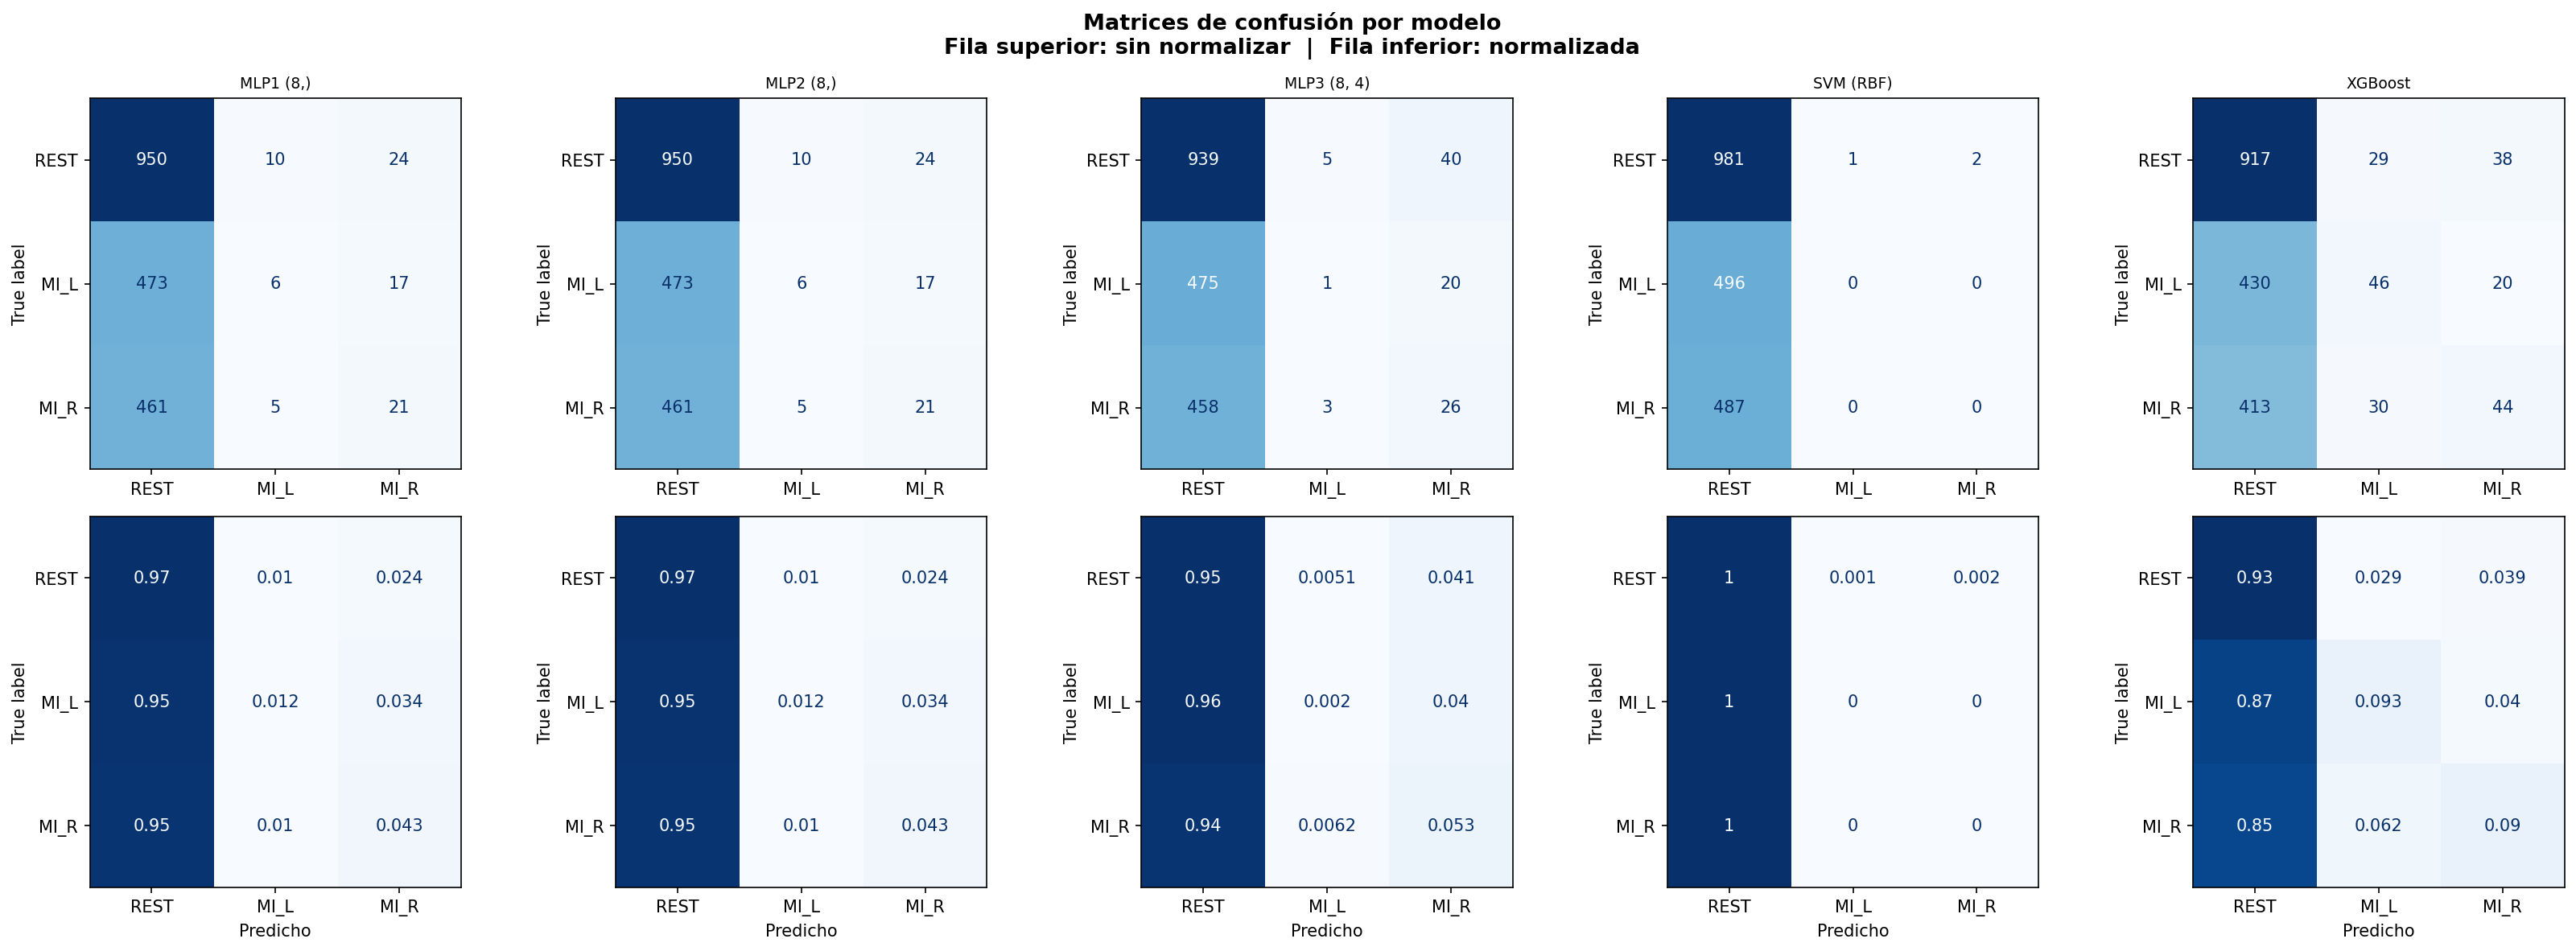

#### **Discusión general de los resultados de clasificación**

El accuracy general (~49–51%) enmascara un problema más grave: la mayoría de los modelos logran ese porcentaje simplemente prediciendo siempre REST, que representa el 50% del dataset. El verdadero indicador de capacidad discriminativa es el recall por clase, donde MLP1, MLP2, MLP3 y SVM obtienen recall prácticamente nulo para MI_L y MI_R. Solo XGBoost muestra evidencia de aprendizaje real, aunque modesto. Este resultado tiene varias causas que se deben discutir en contexto:

1. **Desbalance de clases:** El dataset contiene aproximadamente el doble de épocas REST (4918) que de MI_L (2479) o MI_R (2438). Sin técnicas de remuestreo (SMOTE, class_weight), los clasificadores aprenden a maximizar accuracy prediciendo la clase mayoritaria.

2. **Alta variabilidad inter-sujeto:** Con 109 sujetos y características calculadas globalmente sin normalización por sujeto, la variabilidad individual en amplitud y frecuencia de los ritmos EEG domina sobre los patrones de clase, dificultando el aprendizaje de un clasificador generalizable.

3. **Limitada separabilidad MI_L vs. MI_R:** Las diferencias estadísticas entre estas dos condiciones son mucho menores que las diferencias frente a REST, y afectan principalmente al canal C4. Características más especializadas como CSP habrían ayudado en esta discriminación.

4. **Complejidad del problema:** La clasificación multiclase de imaginería motora con características escalares promediadas por banda es un problema inherentemente difícil sin resolución temporal, algo que métodos como FBCSP o redes convolucionales abordarían mejor.

A pesar de las limitaciones de accuracy absoluta, los análisis estadísticos demuestran que las características extraídas sí contienen información diferenciadora entre condiciones (20 de 24 índices con p < 0.05), lo cual valida el pipeline de extracción de características implementado. La brecha entre significancia estadística y rendimiento de clasificación es explicada por los factores mencionados.

_Figura 9. Comparación de accuracy por fold (StratifiedKFold, k=10) entre los cinco modelos evaluados. La línea discontinua indica el baseline de un clasificador aleatorio para tres clases (33.3%)._
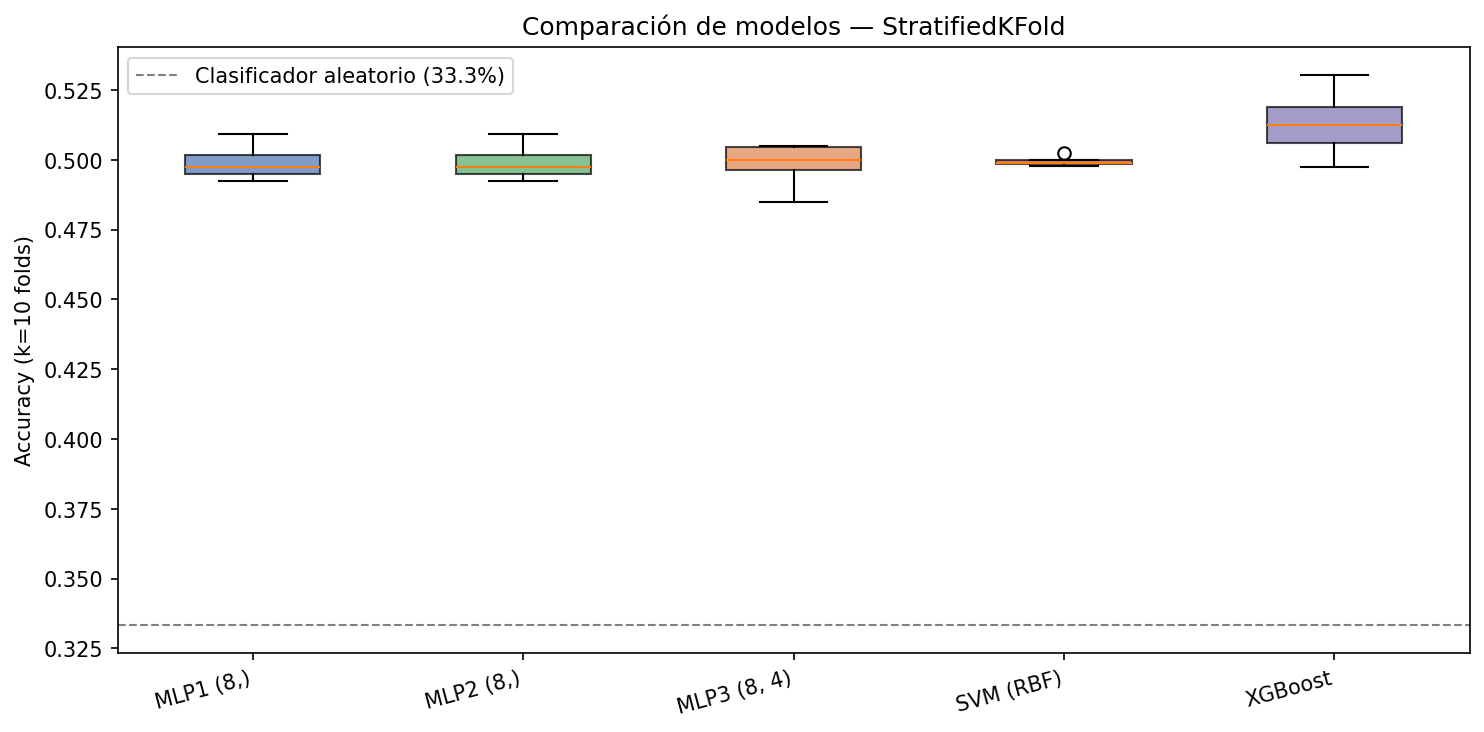

## **CONCLUSIONES**


**1. Sobre el procesamiento y extracción de características EEG**

Se implementó exitosamente un pipeline completo de procesamiento de señales EEG sobre 109 sujetos del dataset PhysioNet EEGBCI (ds004362), obteniendo un DataFrame de 9,835 épocas con 24 características por época, sin valores faltantes. El pipeline de preprocesamiento heredado del Proyecto 1 (filtro pasa-banda 1–40 Hz, filtro notch a 60 Hz y rereferenciación por promedio común) demostró ser robusto para eliminar artefactos y standardizar los datos antes de la extracción de índices. Los cuatro grupos de características implementados —PSD en bandas mu y beta, coherencia espectral, entropía espectral y parámetros de Hjorth— son complementarios entre sí al cubrir dimensiones distintas de la señal EEG: potencia espectral, conectividad funcional, complejidad e irregularidad temporal.

**2. Sobre los índices neurofisiológicos y las diferencias entre condiciones**

El análisis estadístico con Kruskal-Wallis confirmó que 20 de las 24 características extraídas presentan diferencias significativas entre las tres condiciones evaluadas (REST, MI_L, MI_R) con p < 0.05. La diferencia más consistente y robusta es la distinción entre REST y las condiciones de imaginería motora: durante REST se observa mayor potencia mu y beta (ritmos sensoriomotores activos), menor entropía espectral (distribución espectral más concentrada) y mayor actividad de Hjorth (mayor amplitud de señal). Estos patrones son coherentes con el fenómeno de ERD/ERS documentado ampliamente en la literatura BCI. La distinción entre MI_L y MI_R fue significativa en un número más reducido de características, principalmente en la PSD mu del canal C4 y en la entropía de C3 y C4, lo que refleja la lateralización de la actividad sensoriomotora durante la imaginería motora.

**3. Sobre las pruebas estadísticas y la selección de características**

La metodología estadística aplicada —normalidad evaluada con Shapiro-Wilk, comparación global con Kruskal-Wallis y análisis post-hoc con Mann-Whitney U corregido por Bonferroni— fue apropiada para los datos no normales de gran tamaño muestral. El análisis de correlación identificó siete pares de características con redundancia alta (|r| > 0.85), siendo la más notable la correlación entre Actividad de Hjorth y PSD en el mismo canal (r ≈ 0.95–0.97), lo que es explicable porque ambas métricas cuantifican esencialmente la potencia de la señal. La eliminación de características redundantes junto con la selección por significancia estadística permitió reducir el espacio de características de 24 a 8 variables para la clasificación, mejorando la eficiencia computacional sin sacrificar información relevante.

**4. Sobre los clasificadores y el rendimiento del sistema BCI**

Los cinco modelos evaluados (MLP1, MLP2, MLP3, SVM-RBF y XGBoost) obtuvieron accuracies entre 49.9% y 51.3% en validación cruzada con k=10, con XGBoost como el modelo de mejor desempeño (51.29% ± 0.97%). Aunque estos valores son modestos, es importante contextualizarlos: el baseline de un clasificador aleatorio ponderado es de ~50% dado el desbalance de clases (REST representa el 50% de los datos), por lo que el sistema opera apenas por encima del azar. Las tres arquitecturas MLP no mostraron diferencias sustanciales entre sí (~49.9%), lo que indica que la limitación no está en la capacidad de los modelos sino en la separabilidad de las características de entrada. El SVM-RBF demostró la mayor estabilidad entre folds (σ = 0.0012), lo que lo haría preferible en un escenario clínico donde la consistencia es prioritaria sobre la accuracy máxima.

**5. Sobre las limitaciones y perspectivas de mejora**

El rendimiento limitado de los clasificadores se atribuye principalmente a tres factores: el desbalance de clases, la alta variabilidad inter-sujeto inherente a los datos EEG multiusuario, y la escasa separabilidad entre MI_L y MI_R con características escalares promediadas por banda. Para mejorar el sistema en trabajos futuros se propone: (a) aplicar técnicas de balanceo de clases como SMOTE antes del entrenamiento; (b) implementar Common Spatial Patterns (CSP) como paso de preprocesamiento supervisado antes del clasificador, tal como se diseñó en el Plan de Análisis; (c) normalizar características por sujeto antes de la clasificación inter-sujeto; y (d) explorar clasificadores con manejo nativo del desbalance como Random Forest con class_weight='balanced' o redes convolucionales sobre la representación tiempo-frecuencia de la señal.

**6. Relevancia para sistemas BCI no invasivos**

Este proyecto demuestra la viabilidad técnica de implementar un pipeline completo de BCI basado en EEG con herramientas de software libre (MNE, scikit-learn, XGBoost, antropy), procesando datos de 109 sujetos en un entorno reproducible. Los índices extraídos —especialmente PSD mu/beta y entropía espectral— capturan efectivamente los correlatos neurofisiológicos de la imaginería motora descritos en la literatura, lo que valida el enfoque metodológico. Los resultados obtenidos son consistentes con los reportados en sistemas BCI de primera generación basados en características escalares, que históricamente han requerido calibración por sujeto o técnicas de adaptación de dominio para alcanzar rendimientos clínicamente útiles (>70% de accuracy). La combinación de índices espectrales, de conectividad y de complejidad implementada en este proyecto constituye una base sólida para desarrollar sistemas de control motor no invasivo con aplicaciones en asistencia a personas con discapacidades motoras graves.

A partir de los resultados descriptivos obtenidos se observa que las tres hipótesis planteadas son coherentes con los objetivos del estudio y con la literatura sobre sistemas BCI basados en imaginación motora. La PSD fue el índice que mostró las diferencias más evidentes entre condiciones, especialmente en la banda mu, evidenciando fenómenos de desincronización relacionados con la actividad motora imaginada. La entropía espectral presentó incrementos consistentes durante las tareas activas, indicando una mayor complejidad de la señal EEG. Por su parte, la coherencia mostró variaciones más sutiles entre condiciones, sugiriendo que su principal aporte radica en complementar la información proporcionada por la potencia espectral y la entropía. En conjunto, los resultados apoyan las hipótesis alternativas planteadas y justifican el uso combinado de estos índices como variables de entrada para los modelos de clasificación.